Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно. В некоторых заданиях (да и вообще по теме) это дз будет опираться на материал пары.
***

В этом домашнем задании мы (вы) поговорим о, как не странно, **визуализации**. Но говорить о ней надо на каком-то материале. В этот раз немного отдохнем от данных и сами их посоздаем, по моделируем (ну почти).

Я уверена, что вы уже так или иначе владеете кодовыми библиотеками `matplotlib` и `seaborn`, поэтому просто напомню базовый чек-лист из прошлого задания про построение графиков.

- [x] должно быть **понятно**, что изображено на графике;  
- [x] должны присутствовать **названия осей** (за исключением, когда это очевидно);  
- [x] если на графике присутствуют разные данные, то должна быть **легенда**.

В этом дз мы скорее изучим какие-то неочевидные и/или прикольные интересности, чем пройдемся по базовым вещам.  
Для знакомства с базой вот вам [мой любимый простой гайд](https://skillbox.ru/media/code/biblioteka-matplotlib-dlya-postroeniya-grafikov/),
[документация](https://matplotlib.org/3.6.2/users/index.html)
и еще немного материала: [доступен просто так](https://devpractice.ru/matplotlib-lesson-1-quick-start-guide/),
[доступен не просто так](https://pythonworld.ru/novosti-mira-python/scientific-graphics-in-python.html).

# Задание 1: Дискретная непрерывность (2 pt)

Вы знаете, что при $n \rightarrow \infty$ **геометрическое распределение** стремится к **экспоненциальному**
$$\frac{1}{n} Geom\Bigg(\frac{\lambda}{n}\Bigg) \rightarrow Exp(\lambda).$$
Давайте графически это подтвердим!

Для этого нам понадобится:
- [ ] умение [генерировать](####Генерация) случайные величины;
- [ ] умение получать [теоретическую](####Теоретическое-в-коде) плотность;
- [ ] умение [строить](####Построение-графиков) гистограммы;
- [ ] умение [сглаживать](####Сглаживание) данные;
- [ ] умение строить [несколько](####Несколько-графиков) графиков в одной фигуре

*Много теории только тут, дальше столько не будет. Не пропускайте ее, пожалуйста, ну или хотя бы обращайте внимание на выделенное*

#### Генерация

В Python существует **два основных подхода к генерации случайных величин** из различных распределений:  
* `numpy.random`
* `scipy.stats`

В первом случае генерация происходит "на прямую", а во втором как получение выборки конкретной случайной велечины (как метод объекта). Работает `scipy.stats` чуть медленнее, однако это некритично для небольших объемов и точечных вызовов.

Генерация в `numpy.random` происходит через вызов конкретных методов для каждого распределения: `np.random.uniform(a, b, size)`, `np.random.normal(loc, scale, size)`, `np.random.exponential(scale, size)` и так далее.

<div class="alert alert-danger">
<b>ВАЖНО:</b> в экспоненциальном распределении scale = 1/$\lambda$, а не $\lambda$.
</div>

Подробнее как всегда читайте в [документации](https://numpy.org/doc/2.1/reference/random/generator.html), но в этом задании лучше использовать `scipy.stats`.

При этом в обоих случаях не забывайте **фиксировать** `np.random.seed(42)` для **воспроизводимости** результатов!
***

Логика работы со случайными величинами в `scipy.stats` всегда примерно одинаковая:

```python
from scipy import stats

# Создание случайной величины как объекта
xi = stats.norm(loc=0, scale=1)

# Генерация выборки
samples = xi.rvs(size=1000)

pdf_values = xi.pdf(x)      # Плотность вероятности
cdf_values = xi.cdf(x)      # Функция распределения
ppf_values = xi.ppf(q)      # Квантильная функция (обратная CDF)
mean = xi.mean()            # Математическое ожидание
var = xi.var()              # Дисперсия
...
```

При этом в этом модуле реализовано оооооочень много разных распределений!  
| Распределение | Класс | Параметры |
| :------------ | :---- | :-------- |
| **Равномерное** $U(a,b)$ | `stats.uniform` | `loc=a`, `scale=b-a` |
| **Нормальное** $N(\mu,\sigma^2)$ | `stats.norm` | `loc`=$\mu$, `scale`=$\sigma$ |
| **Биномиальное** $Bin(n,p)$ | `stats.binom` | `n`, `p` |
| **Экспоненциальное** $Exp(\lambda)$ | `stats.expon` | `scale`=1/$\lambda$ |
| **Пуассоновское** $Pois(\lambda)$ | `stats.poisson` | `mu`=$\lambda$ |
| **Геометрическое** $Geom(p)$ | `stats.geom` | `p` |
| **Гамма** $Gamma(\alpha,\beta)$ | `stats.gamma` | `a`=$\alpha$, `scale`=1/$\beta$` |
| **Бета** $Beta(\alpha,\beta)$ | `stats.beta` | `a`=$\alpha$, `b`=$\beta$` |
| **Отрицательное биномиальное** $NegBin(r,p)$ | `stats.nbinom` | `n=r`, `p` |
| **Бета-биномиальное** | `stats.betabinom` | `n`, `a`=$\alpha$, `b`=$\beta$` |
| **Стьюдента** $T(d)$ | `stats.t` | `loc=a`, `df=d` |

Как всегда подробнее читайте в [документации](https://docs.scipy.org/doc/scipy/reference/stats.html).

#### Теоретическое в коде


Как было показано ранее из объектов класса распределения можно получать теоретические вещи:
- функцию распределения,
- плотность,
- ожидание,
- дисперсию и так далее
```python
xi = stats.norm(loc=0, scale=1)
cdf_values = xi.cdf(x)
```

Но для дискретных распределений нужно использовать вероятностную массовую функцию (**PMF**), а не плотность (**PDF**). А также их можно получать не от объекта класса, а **через методы сразу**:
```python
binom_pmf = stats.binom.pmf(k, n=100, p=0.05)
```
Для визуализации такого можно использовать `plt.stem()`.

#### Построение графиков

Для построения графиков, очевидно, понадобится `matplotlib.pyplot` или `seaborn`.

Если мы работаем с распределениями, то нам точно понадобятся следующие графики:
| Тип графика | Когда использовать | Пример |
| :---------- | :----------------- | :----- |
| **Гистограмма** (`plt.hist`) | Для отображения эмпирических данных | Приближенная визуализация распределения |
| **Столбчатая диаграмма** (`plt.bar`) | Для дискретных распределений (точное совпадение с целыми значениями) | Визуализация `Pois(λ)` или `Bin(n, p)` без искажения дискретной природы |
| **Линейный график плотности** (`plt.plot`) | Для непрерывных распределений или сглаженных оценок | Наложение теоретической кривой на гистограмму |
| **Точечный график с линиями** (`plt.plot(..., 'o-')`) | Для дискретных распределений при сравнении с теорией | Отображение `pmf` дискретного распределения поверх гистограммы |

**Параметры**

Для лучшей и более понятной визуализации важно уметь работать со следующими параметрами:
| Параметр | За что отвечает | Когда использовать | Пример |
|----------|----------------|-------------------|--------|
| `density=True` | Нормализует гистограмму так, чтобы **площадь = 1** | **Всегда** при сравнении с теоретической плотностью/`pmf` | `plt.hist(data, bins=30, density=True)` |
| `bins` | Количество или границы интервалов гистограммы | Для дискретных распределений: `bins=range(min, max+1)` | `plt.hist(data, bins=range(0, 20))` |
| `alpha` | Прозрачность элемента (0.0–1.0) | При наложении нескольких графиков для видимости перекрытия | `plt.hist(..., alpha=0.6)` |
| `color` / `edgecolor` | Цвет заливки и границ | Для визуального разделения компонентов смеси | `color='skyblue', edgecolor='black'` |
| `label` + `plt.legend()` | Подпись элемента и отображение легенды | При сравнении нескольких распределений на одном графике | `label='Эмпирические данные'` |
| `ax.grid(True, alpha=0.3)` | Добавление сетки | **Всегда** — улучшает читаемость и оценку значений | `ax.grid(True, linestyle='--', alpha=0.3)` |
| `ax.set_xlabel()` / `ax.set_ylabel()` | Подписи осей | **Всегда** — без подписей график непонятен | `ax.set_xlabel('Время между покупками (часы)')` |
| `ax.set_title()` | Заголовок графика | Для краткого описания содержания | `ax.set_title('Сходимость Bin(...) -> Pois(...)')` |
| `ax.annotate()` | Текстовая аннотация со стрелкой | Для выделения ключевых точек (максимумы, пороги) | См. пример ниже |
| `plt.tight_layout()` | Автоматическая настройка отступов | **Перед сохранением** — предотвращает обрезку элементов | `plt.tight_layout()` |
| `dpi` в `savefig()` | Разрешение изображения | Для отчётов: `dpi=150`, для публикаций: `dpi=300` | `plt.savefig('graph.png', dpi=150)` |



Для сравнения данных нам понадобится именно гистограммы (нормированные диаграммы), этого можно добиться при помощи параметра `density=True`: она автоматически нормируется так, чтобы *площадь под диаграммой равнялась 1*.

Подробнее в [документации](https://matplotlib.org/stable/api/pyplot_summary.html).

#### Сглаживание

Когда мы работаем с гистограммой, мы работаем с кусочным объектом, который **зависит от разбиения** (бинов). Поэтому иногда полезно видеть **сглаженную** кривую, которая лучше показывает форму распределения.

Для этой цели можно использовать **ядерное сглаживание** `gaussian_kd`:
* Ядро сглаживания строит гладкую кривую через данные
* Параметр `bw_method` регулирует "гладкость" (по умолчанию — оптимальный)
* Для малых выборок используйте `kde = gaussian_kde(data, bw_method=0.5)`
```python
kde = gaussian_kde(data)
x = np.linspace(min(data), max(data), 1000)
plt.plot(x, kde(x))
```

**Как выбрать** параметр `bw_method`?

```python
# Слишком гладко (теряем детали)
kde1 = gaussian_kde(samples, bw_method=2.0)

# Оптимально (по умолчанию)
kde2 = gaussian_kde(samples, bw_method='scott')  # или 'silverman'

# Слишком "рвано" (шум вместо сигнала)
kde3 = gaussian_kde(samples, bw_method=0.1)
```

<div class="alert alert-danger">
<b>ВАЖНО:</b> Сглаживание может ввести в заблуждение — создать иллюзию непрерывности.
</div>

Подробнее угадайте где? В [документации](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html)!

#### Несколько графиков

Когда нужно сравнить распределения при разных параметрах или показать эволюцию процесса, **одного графика недостаточно**. В этом случае используем **сетку графиков (subplots)**.

**Базовый синтаксис**: `plt.subplots()`

```python
import matplotlib.pyplot as plt

# Создание сетки 2x3 (2 строки, 3 столбца)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
# axes — это двумерный массив объектов осей

# Доступ к отдельным графикам
ax_top_left = axes[0, 0]    # верхний левый
ax_bottom_right = axes[1, 2]  # нижний правый

# Если нужен одномерный массив (удобнее для циклов)
axes_flat = axes.flatten()  # превращает (2,3) → (6,)
```

**Ключевые параметры**:

| Параметр | За что отвечает | Пример |
| :------- | :-------------- | :----- |
| `nrows`, `ncols` | Количество строк и столбцов |  `plt.subplots(2, 3)` -> сетка 2x3 |
| `figsize=(w, h)` | Размер всей фигуры в дюймах | `figsize=(14, 6)` — широкая фигура для горизонтального сравнения |
| `sharex=True/False` | Общая ось X для всех графиков | При сравнении распределений с одинаковым диапазоном значений |
| `sharey=True/False` | Общая ось Y для всех графиков | При сравнении плотностей или диаграмм с одинаковым масштабом |
| `squeeze=True` *(по умолчанию)* | Упрощает форму массива `axes` | При `nrows=1`, `ncols=1` возвращает один объект `ax`, а не массив 1x1 |
| `gridspec_kw` | Тонкая настройка размеров ячеек | `gridspec_kw={'width_ratios': [2, 1]}` — первый график в 2 раза шире второго |

Ну и подробнее в любимой [документации](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html).

***
## Задание (2 pt)

Изучите приближение геометрического распределения к экспоненциальному через визуализацию.

**Постройте сетку 2×2 графиков для разных значений $n$ (20, 50, 100, 1000) при фиксированном значении $\lambda=2$**  
**На каждом графике** отобразите:
- гистограмму выборки из $\frac{1}{n} Geom\big(\frac{\lambda}{n}\big)$,
- теоретическую плотность соответствующего экспоненциального,
- сглаженную плотность из данных,
- легенду с нужными значениями.

Для этого используйте нужные виды графиков, цветовую дифференциацию, правильные подписи и вообще _**всю красоту**_.

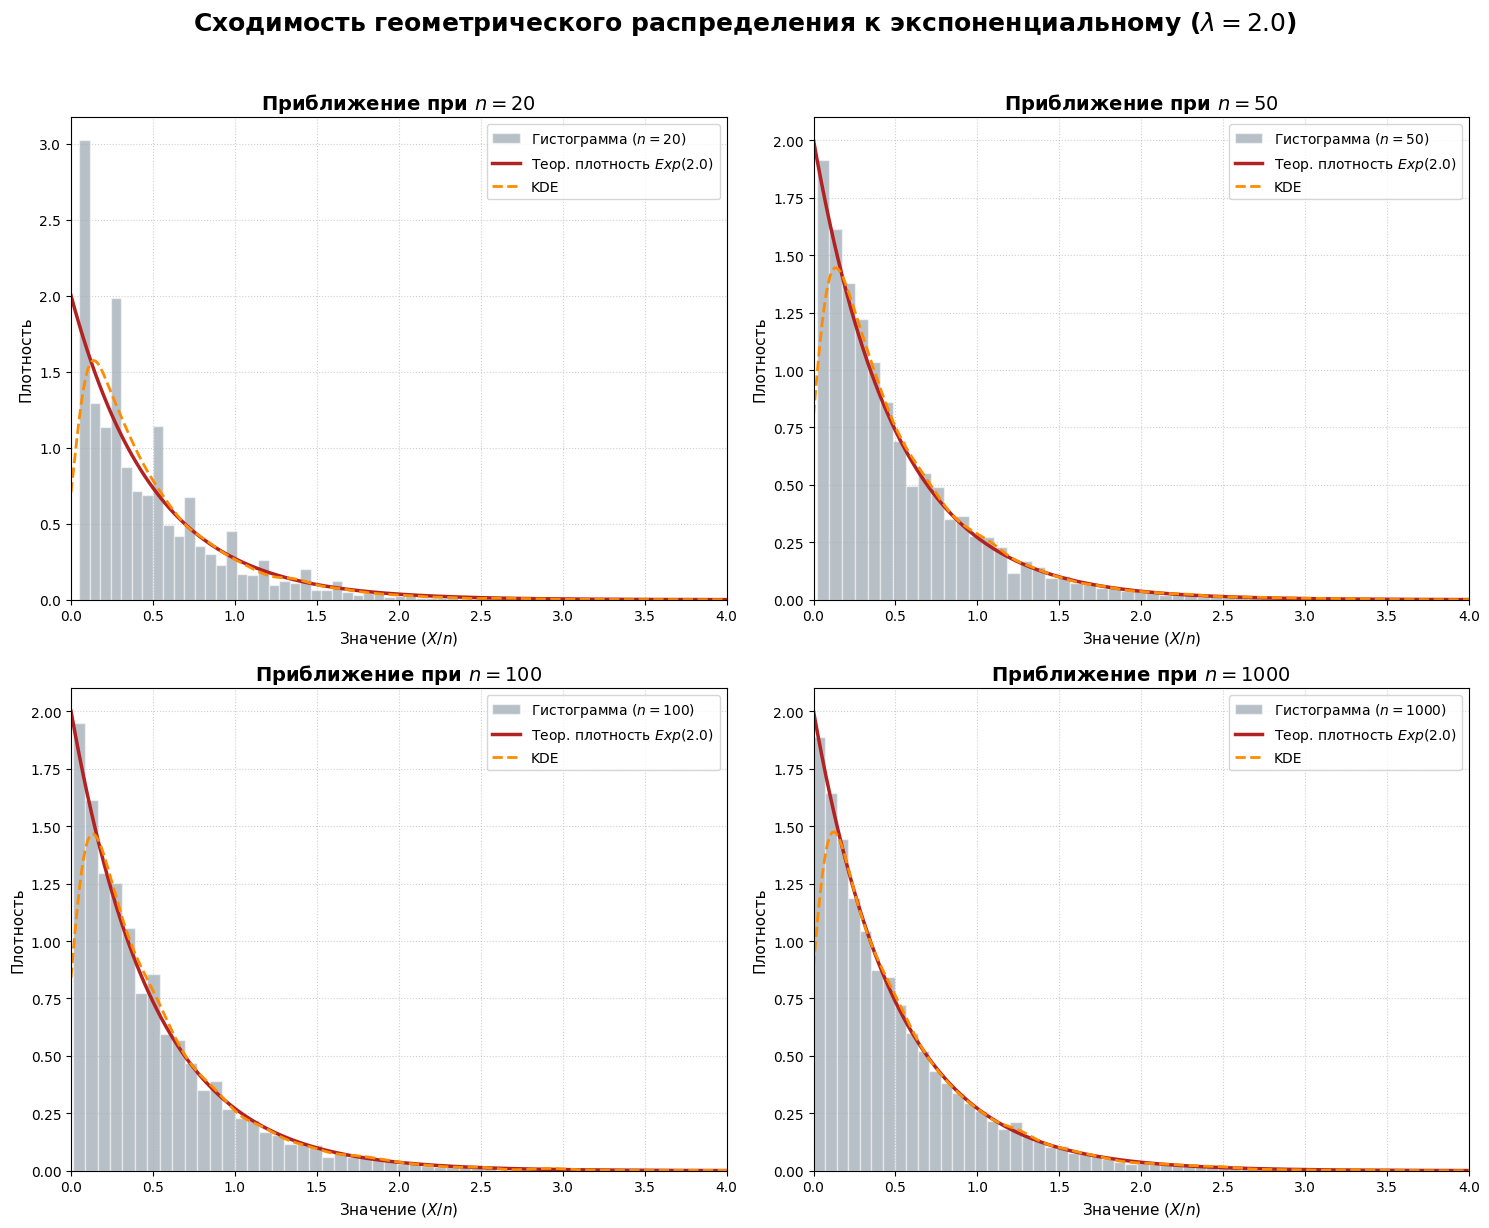

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde

np.random.seed(42)
lambda_param = 2.0
n_values = [20, 50, 100, 1000]
n_samples = 10000  

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, n in enumerate(n_values):
    ax = axes[idx]
    
    p = lambda_param / n
    geom_samples = stats.geom.rvs(p, size=n_samples)
    data = geom_samples / n
    
    ax.hist(data, bins=60, density=True, color='slategray', alpha=0.5, 
            edgecolor='white', label=f'Гистограмма ($n={n}$)')
    
    x_vals = np.linspace(0, 5, 400)
    exp_pdf = stats.expon.pdf(x_vals, scale=1/lambda_param)
    ax.plot(x_vals, exp_pdf, color='firebrick', lw=2.5, label=f'Теор. плотность $Exp({lambda_param})$')
    
 
    kde_func = gaussian_kde(data)
    ax.plot(x_vals, kde_func(x_vals), color='darkorange', lw=2, linestyle='--', label='KDE')
  
    ax.set_xlabel('Значение ($X/n$)', fontsize=11)
    ax.set_ylabel('Плотность', fontsize=11)
    ax.set_title(f'Приближение при $n = {n}$', fontsize=14, fontweight='bold')
    
    ax.set_xlim(0, 4)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.6)

fig.suptitle(f'Сходимость геометрического распределения к экспоненциальному ($\lambda = {lambda_param}$)', fontsize=18, y=1.02, fontweight='bold')

plt.tight_layout()


plt.show()

### Вывод

Таким образом, по графикам видно, что при увелечении n, 
$$\frac{1}{n} Geom\Bigg(\frac{\lambda}{n}\Bigg) \rightarrow Exp(\lambda).$$

также видно, что сглаживание немного плохо работает с экспонентой, это связано с ядром гаусса, я пробовала менять параметры и размер выборки, потом поняла, что проблема именно в ядре. при этом с другими распределенями, не такими резкими, как экспонента, сглаживание работает круче и красивее.

# Задание 2: Не детские смеси (3 pt)

В этом задании мы повизуализируем смеси. Все нужые **ссылки и прочее уже были даны ранее**, добавлю только несколько фич:

| Фича | Метод | Зачем использовать |
| :--- | :---- | :----------------- |
| **Аннотации со стрелками** | `ax.annotate()` | Выделение ключевых точек графика с визуальной связью между текстом и объектом |
| **Текстовые блоки с фоном** | `ax.text()` + `bbox` | Добавление поясняющего текста с выделением фона для читаемости |
| **Вертикальные/горизонтальные линии** | `ax.axvline()`, `ax.axhline()` | Выделение порогов, средних значений, квантилей |
| **Заливка областей** | `ax.fill_between()`, `axvspan()` | Визуализация доверительных интервалов, выделение зон интереса |
| **Настройка шрифтов** | `fontdict`, `fontsize` | Единый стиль оформления текстовых элементов |
| **Стили линий и маркеров** | `linestyle`, `marker` | Различение нескольких кривых без цвета |

У всего этого куча интересных параметров, за ними идите в [ДО](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.annotate.html)
[КУ](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.text.html)
[МЕН](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.axvline.html)
[ТА](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.fill_between.html)
[ЦИ](https://matplotlib.org/stable/gallery/text_labels_and_annotations/accented_text.html)
[Ю](https://matplotlib.org/stable/gallery/text_labels_and_annotations/annotation_basic.html)!

## «Теоретическое» задание (1,5 pt)

Смоделируйте **загрязнённое нормальное распределение**, которое можно встретить, например, в ситуации, когда есть основная группа пользователей и малая часть "активных"

$$(1 - \varepsilon) \cdot N(\mu, \sigma^2) + \varepsilon \cdot N(\mu, \alpha\sigma^2).$$

Ваша **необходимо**:
1. Сгенерировать **выборку** из загрязненного нормального распределения с параметрами:
   - $\mu = 0$, $\sigma =  1$
   - $\varepsilon = 0.15$ *(вот тут появляется Бернулли)*
   - $\alpha = 4$
2. Построить **один график** со следующими элементами:
   - Гистограмма эмпирических данных (серый цвет, `alpha=0.6`)
   - Теоретическая плотность основного компонента (синяя линия, `alpha=0.7`)
   - Теоретическая плотность загрязняющего компонента (красная линия, `alpha=0.7`)
   - Полная теоретическая плотность смеси (чёрная пунктирная линия, толщина 2.5)
   - Сравнение с "чистым" нормальным распределением (фиолетовая штрихпунктирная линия) — *чтобы показать, как загрязнение искажает форму*
   - Аннотация со стрелкой, указывающая на "тяжёлые хвосты" от загрязняющего компонента
   - Текстовый блок с параметрами смеси и интерпретацией (используйте `bbox`)

В этом задании для генерации используем `numpy.random`.

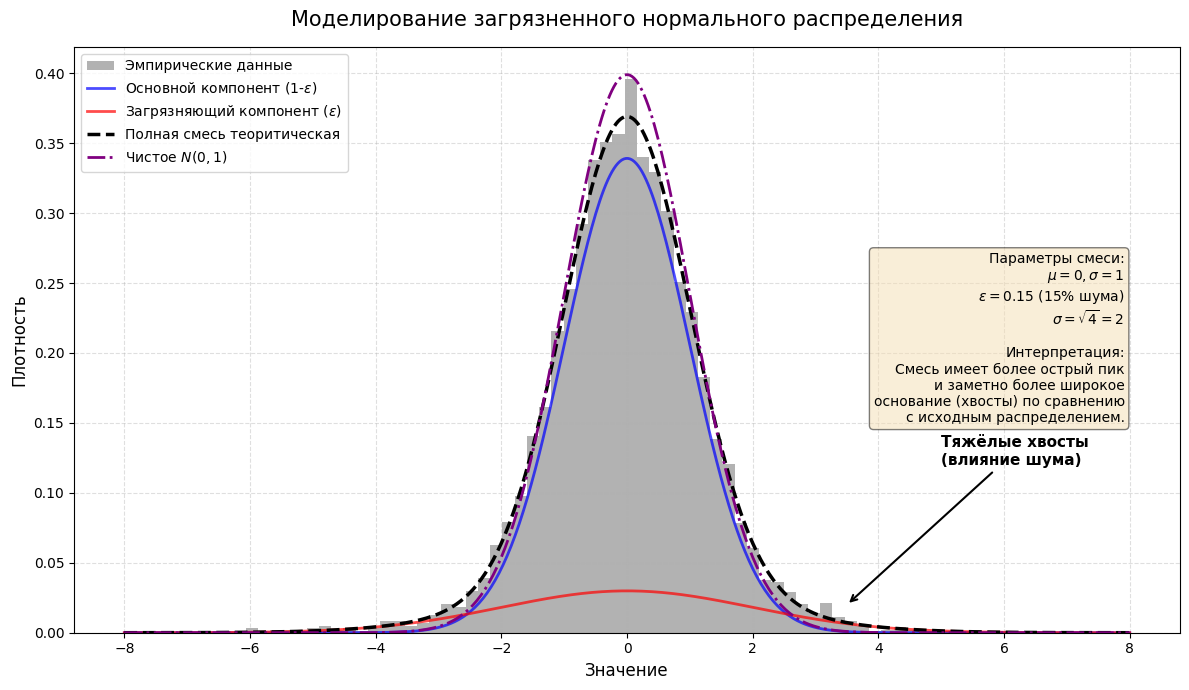

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

mu = 0
sigma = 1
epsilon = 0.15  
alpha = 4       
n_samples = 5000

is_contaminated = np.random.binomial(1, epsilon, n_samples)
main_component = np.random.normal(mu, sigma, n_samples)

contaminated_component = np.random.normal(mu, np.sqrt(alpha) * sigma, n_samples)

mixture = np.where(is_contaminated == 1, contaminated_component, main_component)

fig, ax = plt.subplots(figsize=(12, 7))


ax.hist(mixture, bins=60, density=True, color='gray', alpha=0.6, label='Эмпирические данные')


x_vals = np.linspace(-8, 8, 500)


main_pdf = (1 - epsilon) * stats.norm.pdf(x_vals, mu, sigma)
ax.plot(x_vals, main_pdf, color='blue', alpha=0.7, lw=2, label='Основной компонент (1-$\epsilon$)')

contaminated_pdf = epsilon * stats.norm.pdf(x_vals, mu, np.sqrt(alpha) * sigma)
ax.plot(x_vals, contaminated_pdf, color='red', alpha=0.7, lw=2, label='Загрязняющий компонент ($\epsilon$)')


mixture_pdf = main_pdf + contaminated_pdf
ax.plot(x_vals, mixture_pdf, color='black', linestyle='--', lw=2.5, label='Полная смесь теоритическая')


pure_normal_pdf = stats.norm.pdf(x_vals, mu, sigma)
ax.plot(x_vals, pure_normal_pdf, color='purple', linestyle='-.', lw=2, label='Чистое $N(0, 1)$')

ax.annotate('Тяжёлые хвосты\n(влияние шума)', xy=(3.5, 0.02), xytext=(5, 0.12), arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),fontsize=11, fontweight='bold')

interpretation_text = (
    f"Параметры смеси:\n"
    f"$\mu={mu}, \sigma={sigma}$\n"
    f"$\epsilon={epsilon}$ (15% шума)\n"
    f"$\sigma = \sqrt{{4}} = 2$\n\n"
    "Интерпретация:\n"
    "Смесь имеет более острый пик\n"
    "и заметно более широкое\n"
    "основание (хвосты) по сравнению\n"
    "с исходным распределением."
)
ax.text(0.95, 0.65, interpretation_text, transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


ax.set_xlabel('Значение', fontsize=12)
ax.set_ylabel('Плотность', fontsize=12)
ax.set_title('Моделирование загрязненного нормального распределения', fontsize=15, pad=15)
ax.legend(loc='upper left', frameon=True)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Что мы в итоге поняли:**
1. **Хвосты стали «тяжелыми»:** На графике видно, что там, где обычное нормальное распределение (фиолетовая линия) уже закончилось, наша смесь (черная пунктирная линия) все еще продолжается. Это происходит из-за загразнения, которое мы добавили.
2. **Форма изменилась:** Из-за загрязнения (красная линия) с большой дисперсией, график стал шире у основания.

**Итог:** Даже небольшое загрязнение выборки (всего 15%) меняет форму распределения.

## Практическое задание (1,5 pt)

В этом задании мы все же поработаем с данными, но с теми, с которыми вы уже знакомы! Будем снова говорить про пингвинчиков)

Вам **необходимо**:
1. Загрузить датасет и удалить строки с пропущенными значениями в столбце `bill_length_mm`
2. Построить **два графика** на **одной фигуре** (сетка 1×2):
   - Левый график: **Общая гистограмма** длины клюва всех пингвинов + наложенные плотности для каждого вида (разные цвета, `alpha=0.6`)
   - Правый график: **Три отдельные гистограммы** по видам (на одном графике для сравнения) с **теоретическими нормальными кривыми**
3. На левом графике добавьте:
   - **Аннотацию со стрелкой на бимодальность** (место между пиками)
   - **Текстовый блок с интерпретацией**: почему общее распределение выглядит как смесь?
   - **Вертикальные линии**, показывающие средние значения для каждого вида
4. На правом графике добавьте:
   - **Легенду** с указанием вида и количества особей
   - **Подпись с выводом**: *какой вид имеет наибольшую вариабельность длины клюва?*

In [3]:
import seaborn as sns
penguins = sns.load_dataset('penguins')
penguins_clean = penguins.dropna(subset=['bill_length_mm'])


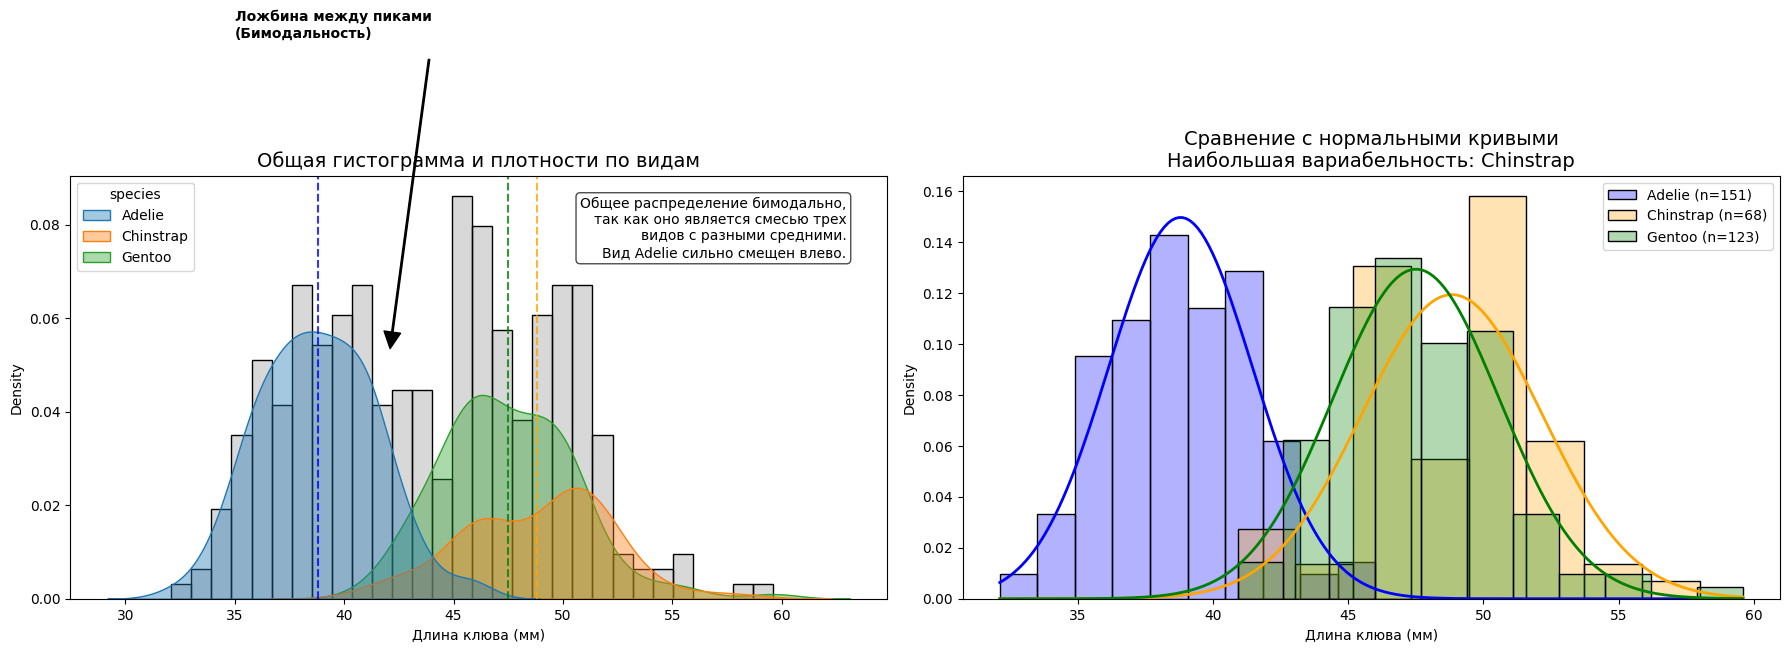

In [4]:
# разделение по видам
adelie = penguins_clean[penguins_clean['species'] == 'Adelie']['bill_length_mm']
chinstrap = penguins_clean[penguins_clean['species'] == 'Chinstrap']['bill_length_mm']
gentoo = penguins_clean[penguins_clean['species'] == 'Gentoo']['bill_length_mm']
all_penguins = penguins_clean['bill_length_mm']

# вычисление параметров для нормальных кривых
mu_adelie, std_adelie = adelie.mean(), adelie.std()
mu_chinstrap, std_chinstrap = chinstrap.mean(), chinstrap.std()
mu_gentoo, std_gentoo = gentoo.mean(), gentoo.std()

# графики (сетка 1x2)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# левый график
ax1 = axes[0]
sns.histplot(all_penguins, bins=30, kde=False, stat="density", color='gray', alpha=0.3, ax=ax1, label='Все пингвины')
sns.kdeplot(data=penguins_clean, x='bill_length_mm', hue='species', fill=True, alpha=0.4, ax=ax1)

# вертикальные линии средних
ax1.axvline(mu_adelie, color='blue', linestyle='--', alpha=0.8, label=f'Mean Adelie: {mu_adelie:.1f}')
ax1.axvline(mu_chinstrap, color='orange', linestyle='--', alpha=0.8, label=f'Mean Chinstrap: {mu_chinstrap:.1f}')
ax1.axvline(mu_gentoo, color='green', linestyle='--', alpha=0.8, label=f'Mean Gentoo: {mu_gentoo:.1f}')

# аннотация на бимодальность
ax1.annotate('Ложбина между пиками\n(Бимодальность)', xy=(42, 0.05), xytext=(35, 0.12), arrowprops=dict(facecolor='black', shrink=0.05, width=1), fontsize=10, fontweight='bold')

# текстовый блок с интерпретацией
interpretation_text = ("Общее распределение бимодально,\n"
                       "так как оно является смесью трех\n"
                       "видов с разными средними.\n"
                       "Вид Adelie сильно смещен влево.")
ax1.text(0.95, 0.95, interpretation_text, transform=ax1.transAxes, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax1.set_title('Общая гистограмма и плотности по видам', fontsize=14)
ax1.set_xlabel('Длина клюва (мм)')

# правый график
ax2 = axes[1]
colors = ['blue', 'orange', 'green']
species_data = [(adelie, 'Adelie', mu_adelie, std_adelie), (chinstrap, 'Chinstrap', mu_chinstrap, std_chinstrap), (gentoo, 'Gentoo', mu_gentoo, std_gentoo)]

x_range = np.linspace(all_penguins.min(), all_penguins.max(), 200)

for i, (data, name, mu, std) in enumerate(species_data):
    # гистограммы
    sns.histplot(data, stat="density", color=colors[i], alpha=0.3, ax=ax2, label=f'{name} (n={len(data)})')
    # теоритические кривые
    ax2.plot(x_range, stats.norm.pdf(x_range, mu, std), color=colors[i], lw=2)

# вывод о вариабельности 
stds = {"Adelie": std_adelie, "Chinstrap": std_chinstrap, "Gentoo": std_gentoo}
max_var_species = max(stds, key=stds.get)
ax2.set_title(f'Сравнение с нормальными кривыми\nНаибольшая вариабельность: {max_var_species}', fontsize=14)
ax2.set_xlabel('Длина клюва (мм)')
ax2.legend()

plt.tight_layout()
plt.show()

# Задание 3: Buy Till You Die (5 pt)

В этом задании мы поработаем с моделью, которая может пригодиться при аналитике реальных процессов. Напоминаю:

> Предположим, что после первой покупки, пользователи ведут себя так:  
> С вероятностью `𝑝` он перестает пользоваться сервисом, а с вероятностью `1 − 𝑝` не перестает.
> Тем самым количество покупок имеет распределение `𝐺𝑒𝑜𝑚(𝑝)`. Такой способ моделировать «смерть» пользователя называется **Buy Till You Die (BTYD)**  
> Если покупатель не перестал пользоваться сервисом, то следующая покупка происходит через время `𝐸𝑥𝑝(𝜆)`  
> У каждого пользователя параметры `𝑝` и `𝜆` свои, и **вариабельность в их значениях** моделируются с помощью `𝐵𝑒𝑡𝑎(𝛼𝑝,𝛽𝑝)` для `𝑝` и `𝐺𝑎𝑚𝑚𝑎(𝛼𝜆, 𝛽𝜆)` для `𝜆`.  
> Получившуюся модель называют **Beta-Geometric/Negative Binomial Distribution (BG/NBD)**.


### Теоретическое задание (1,5 pt)

Пусть в момент последней активности пользователь с вероятностью $p$ ушел, и, стало быть, с вероятностью $1−p$ остался. Если пользователь остался, то его следующая активность случится через время $T$, которое имеет распределение $Exp(q)$.

Выразите через $p$, $q$ и $t$ вероятность того, что **пользователь остался при условии, что он не проявлял активность в течение времени** $t$.

В КАЧЕСТВЕ РЕШЕНИЯ ОЖИДАЕТСЯ ФОРМУЛА И ТО, КАК ВЫ ЕЕ ПОЛУЧИЛИ (С ПОЯСНЕНИЕМ РАССУЖДЕНИЙ)


#### Вероятность того, что пользователь остался, если он не проявлял активность

* $A$ — пользователь **остался**;
* $B$ — пользователь **не проявлял активность** до времени $t$ ($T > t$).

1. По попределению условной вероятности:
$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$

2. Числитель: $P(A \cap B)$

$P(A \cap B) = P(B \mid A) P(A)$

Вероятность того, что пользователь остался и при этом не проявлял активность:

* $P(A) = 1 - p$ 
* Если пользователь остался, время до следующей активности распределено экспоненциально: $T \sim \mathrm{Exp}(q)$.
* Тогда вероятность отсутствия активности до момента $t$:
    $$P(B \mid A) = P(T > t) = e^{-qt}$$

пользователь не проявлял активность при условии, что пользователь остался, по сути это независимые события, почему? если вспомнить процесс пуассона, где каждая точка это пользователь совершает покупку (ну то есть остается), то у нас есть теорема, которая говорит, что знание того, сколько событий произошло до момента 𝑡, никак не влияет на распределение времени до следующего события. поэтому это будет просто вероятность события B, ну то есть $e^{-qt}$

(ниже скрин из методички  Тимофея Вячеславовича, вот там как раз свойство (iii) это то, что я здесь использую)

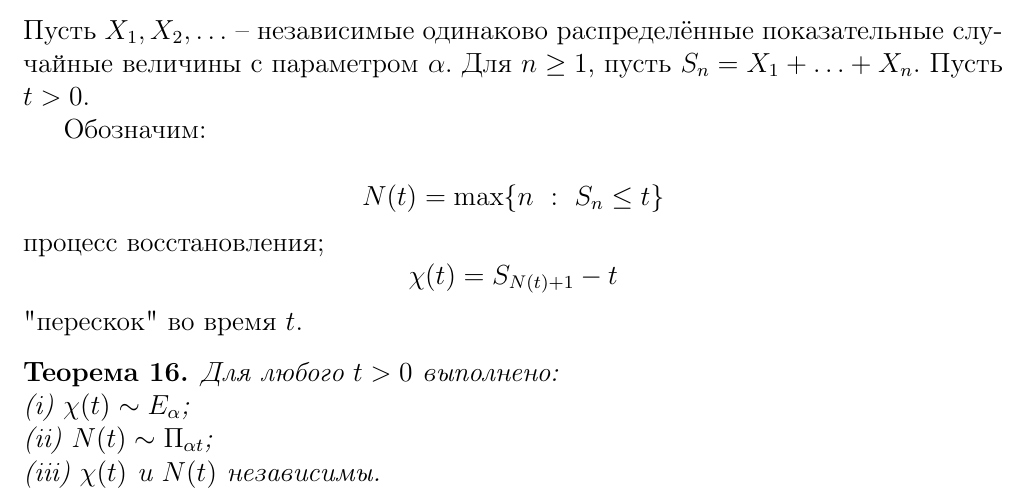

Ну и так как они независимы, по определению это просто произведение вероятностей P(A)*P(B)
$$P(A \cap B) = (1 - p) e^{-qt}$$


3. Знаменатель: $P(B)$

Используем формулу полной вероятности. Событие $B$ может произойти в двух случаях: пользователь остался, но молчит, либо пользователь ушел навсегда.

$$P(B) = P(B \mid A) P(A) + P(B \mid \bar{A}) P(\bar{A})$$

Где:
* $P(\bar{A}) = p$ — вероятность того, что пользователь ушел.
* Для ушедшего пользователя активности не будет со стопроцентной вероятностью: $P(B \mid \bar{A}) = 1$. (очевидно, если пользователь ушел, то след. покупки не будет)

Итого:
$$P(B) = (1 - p) e^{-qt} + p \cdot 1$$



4. Итоговая формула

Подставляем полученные выражения в исходное уравнение:

$$\boxed{P(A \mid B) = \frac{(1 - p) e^{-qt}}{p + (1 - p)e^{-qt}}}$$


### Практическое задание (3,5 pt)

Будем использовать публичный датасет `CDNOW` — классический датасет для анализа поведения покупателей (покупки музыки онлайн в 1997-98 годах). Датасет содержит:
- `customer_id` — идентификатор покупателя
- `date` — дата покупки
- `quantity` — количество купленных альбомов
- `value` — сумма покупки в долларах

Ваша задача: **построить график** 2x2, отвечающий на **4 бизнес-вопроса**:

| Подграфик | Вопрос | Требования |
| :-------- | :----- | :--------- |
| **Верхний левый** | Как распределено количество покупок на пользователя? | Гистограмма с `bins=range(1, max_quantity+1)` <br> Теоретическая кривая геометрического распределения <br> Аннотация с указанием доли «одноразовых» покупателей |
| **Верхний правый** | Как распределено время между покупками? | Гистограмма с `density=True` <br> Теоретическая кривая экспоненциального распределения <br> Вертикальная линия на медиане времени между покупками |
| **Нижний левый** | Какова вероятность «смерти» пользователя в зависимости от времени с последней покупки? | Кривая функции выживания `S(t)=P(T>t)` <br> Кривая «риска смерти» `h(t)=1−S(t)` <br> Заливка области под кривой риска (`fill_between`) |
| **Нижний правый** | Сколько покупок совершит пользователь за следующие 30 дней? | Гистограмма прогноза (сгенерированная через симуляцию) <br> Вертикальная линия на математическом ожидании прогноза <br> Доверительный интервал 95% через заливку (`axvspan`) |

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('cdnow.csv', index_col=0)
print(df.head(10))

   customer_id        date  quantity  price
0            1  1997-01-01         1  11.77
1            2  1997-01-12         1  12.00
2            2  1997-01-12         5  77.00
3            3  1997-01-02         2  20.76
4            3  1997-03-30         2  20.76
5            3  1997-04-02         2  19.54
6            3  1997-11-15         5  57.45
7            3  1997-11-25         4  20.96
8            3  1998-05-28         1  16.99
9            4  1997-01-01         2  29.33


In [6]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['customer_id', 'date']).reset_index(drop=True)
print(df.head(10))

   customer_id       date  quantity  price
0            1 1997-01-01         1  11.77
1            2 1997-01-12         1  12.00
2            2 1997-01-12         5  77.00
3            3 1997-01-02         2  20.76
4            3 1997-03-30         2  20.76
5            3 1997-04-02         2  19.54
6            3 1997-11-15         5  57.45
7            3 1997-11-25         4  20.96
8            3 1998-05-28         1  16.99
9            4 1997-01-01         2  29.33


2       0.0
4      87.0
5       3.0
6     227.0
7      10.0
8     184.0
10     17.0
11    196.0
12    132.0
14     13.0
Name: delta_days, dtype: float64
Оценка параметра экспоненты q_hat = 0.0145
customer_id
1    545
2    534
3     33
4    200
5    178
Name: date, dtype: int64


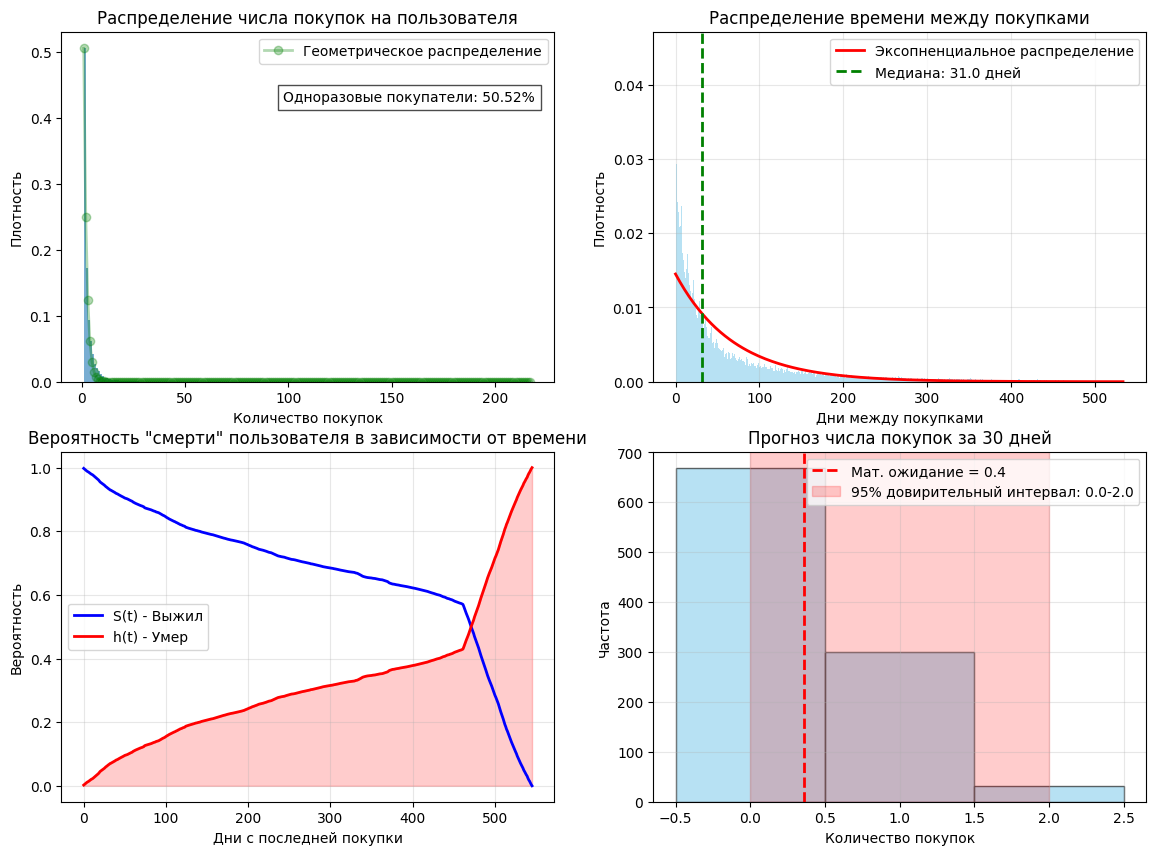

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

axes[0].set_title('Распределение числа покупок на пользователя')
axes[1].set_title('Распределение времени между покупакми')
axes[2].set_title('Вероятность "смертри" в зав-ти от времени с последней покупки')
axes[3].set_title('Сколько покупок совершит пользователь за следующие 30 дней')

# верхний левый

buy_user = df.groupby('customer_id').size()
max_quantity = buy_user.max()
bins = range(1, max_quantity + 2)
axes[0].hist(buy_user, bins = bins, density = True, alpha = 0.6)
axes[0].set_xlabel('Количество покупок')
axes[0].set_ylabel('Плотность')

p_hat = (buy_user == 1).mean()
k_vals = np.arange(1, max_quantity + 1)
geom_pmf = p_hat * (1 - p_hat) ** (k_vals - 1)
axes[0].plot(k_vals, geom_pmf, marker='o', linewidth=2, color='green', label='Геометрическое распределение', alpha = 0.3)
axes[0].legend()
axes[0].text( 0.45 , 0.8, f'Одноразовые покупатели: {p_hat:.2%}', transform=axes[0].transAxes,bbox=dict(facecolor='white', alpha=0.7))

# верхний правый 

df['date'] = pd.to_datetime(df['date'])

# сортируем по пользователю и дате
df = df.sort_values(['customer_id', 'date']).reset_index(drop=True)

# вычисляем дату предыдущей покупки
df['prev_date'] = df.groupby('customer_id')['date'].shift(1)

# разница в днях между текущей и предыдущей покупкой
df['delta_days'] = (df['date'] - df['prev_date']).dt.days

# убираем NaN (первые покупки у каждого пользователя)
inter_purchase_times = df['delta_days'].dropna()

print(inter_purchase_times.head(10))

q_hat = 1 / inter_purchase_times.mean()
print(f"Оценка параметра экспоненты q_hat = {q_hat:.4f}")


axes[1].set_title('Распределение времени между покупками')
axes[1].set_xlabel('Дни между покупками')
axes[1].set_ylabel('Плотность')

# гистограмма
bins = np.arange(0, inter_purchase_times.max() + 2)
axes[1].hist(inter_purchase_times, bins=bins, density=True, alpha=0.6, color='skyblue')

# теоретическая кривая экспоненты
x_vals = np.linspace(0, inter_purchase_times.max(), 200)
exp_pdf = q_hat * np.exp(-q_hat * x_vals)
axes[1].plot(x_vals, exp_pdf, color='red', lw=2, label='Эксопненциальное распределение')

# медиана времени
median_time = inter_purchase_times.median()
axes[1].axvline(median_time, color='green', linestyle='--', lw=2, label=f'Медиана: {median_time} дней')

axes[1].legend()
axes[1].grid(alpha=0.3)

#нижний левый 

max_date = df['date'].max()

# последнее время покупки каждого пользователя
last_purchase = df.groupby('customer_id')['date'].max()

# время с последней покупки до конца наблюдения (в днях)
time_since_last = (max_date - last_purchase).dt.days

print(time_since_last.head())

t_values = np.arange(0, time_since_last.max() + 1)
S_t = np.array([(time_since_last > t).mean() for t in t_values])
h_t = 1 - S_t

axes[2].set_title('Вероятность "смерти" пользователя в зависимости от времени')
axes[2].set_xlabel('Дни с последней покупки')
axes[2].set_ylabel('Вероятность')

# функция выживания
axes[2].plot(t_values, S_t, color='blue', lw=2, label='S(t) - Выжил')

# функция риска
axes[2].plot(t_values, h_t, color='red', lw=2, label='h(t) - Умер')

# заливка под кривой риска
axes[2].fill_between(t_values, 0, h_t, color='red', alpha=0.2)

axes[2].legend()
axes[2].grid(alpha=0.3)

#нижний правый

n_sim = 1000  # число симуляций пользователей
forecast_days = 30
sim_purchases = []

for _ in range(n_sim):
    t = 0
    count = 0
    alive = True
    while t < forecast_days and alive:
        # время до следующей покупки
        dt = np.random.exponential(1/q_hat)
        t += dt
        if t > forecast_days:
            break
        count += 1
        # с вероятностью p_hat пользователь «умер»
        alive = np.random.rand() > p_hat
    sim_purchases.append(count)

sim_purchases = np.array(sim_purchases)
axes[3].set_title('Прогноз числа покупок за 30 дней')
axes[3].set_xlabel('Количество покупок')
axes[3].set_ylabel('Частота')

# гистограмма прогноза
axes[3].hist(sim_purchases, bins=np.arange(0, sim_purchases.max()+2)-0.5,
             density=False, alpha=0.6, color='skyblue', edgecolor='black')

# среднее
mean_forecast = sim_purchases.mean()
axes[3].axvline(mean_forecast, color='red', linestyle='--', lw=2, label=f'Мат. ожидание = {mean_forecast:.1f}')

# доверительный интервал 95%
ci_lower = np.percentile(sim_purchases, 2.5)
ci_upper = np.percentile(sim_purchases, 97.5)
axes[3].axvspan(ci_lower, ci_upper, color='red', alpha=0.2, label=f'95% довирительный интервал: {ci_lower}-{ci_upper}')

axes[3].legend()
axes[3].grid(alpha=0.3)


**НАПИШИТЕ ВЫВОДЫ ПО ГРАФИКАМ, КОТОРЫЕ БЫ ВЫ СДЕЛАЛИ, КАК АНАЛИТИК (ОТВЕТЫ НА ВОПРОСЫ + РАССУЖДЕНИЯ)**

**1️.Верхний левый график — распределение числа покупок на пользователя**

* Основная масса пользователей совершает 1 покупку.
* Есть длинный хвост активных пользователей, которые совершают десятки покупок.
* Геометрическое распределение  хорошо описывает общую тенденцию. Вероятность ухода постоянна для каждой следующей покупки. (визуализация подтверждает теорию из матстата)
* **Вывод:** почти половина пользователей  одноразовые, но есть хвост активных клиентов.


**2️. Верхний правый график — распределение времени между покупками**

* Большинство интервалов между покупками короткие (1–50 дней), но есть редкие интервалы "долгие", больше сотни.
* Экспонента примерно повторяет форму эмпирического распределения, что подтверждает то, что процесс "без памяти"(это св-во из матстата): вероятность следующей покупки не зависит от того, сколько дней прошло.
* Медиана времени между покупками = 31 день половина всех интервалов меньше этого значения.
* **Вывод:** активность концентрируется на первых месяцах после покупки.

**3️. Нижний левый график — функция выживания и риск «смерти» пользователя**

* Синяя кривая (S(t)) показывает, что большинство уходов происходит в первые 100–150 дней.
* Красная кривая (h(t)) (риск «смерти») нарастает постепенно, а затем стабилизируется: оставшиеся пользователи становятся лояльными.
* Заливка под кривой риска визуализирует интенсивность ухода пользователей с течением времени.
* **Вывод:** в первые 1–4 месяца риск ухода высокий, а долгосрочные пользователи меньше подвержены «смерти».

**4️. Нижний правый график — прогноз числа покупок за 30 дней**

* Среднее число покупок = 0.4, что говорит, что пользователи в среднем совершают меньше одной покупки за месяц.
* 95% доверительный интервал [0–2] показывает, что большинство пользователей совершает 0–2 покупки, но есть редкие активные пользователи с большим числом покупок.
* **Вывод:** за месяц активность пользователей низкая, но небольшая часть может дать существенный вклад. 



# Бонус с собеса (2+ pt)

Мне понравилась задачка с собеседования, поэтому показываю ее вам:

> На маркетплейсе есть $n$ категорий товаров, в каждой из которых есть $n_i$ различных позиций товаров. Пользователь собирает корзину, делая покупки из любых категорий (может взять из категории, может не взять, может взять из нескольких). Известно, что **средний чек по каждой из категорий** вырос за последний месяц. Что могло произойти с **общим средним чеком**?

Сначала поймите, как считается общий чек. В рассуждениях вы свободны, главное оформите так, чтобы я могла _**понять, где ваш ответ и выводы, на чем они основаны**_. Вы можете делать теоретические выкладки, симуляции и визуализацию. Ничего из этого не запрещено.